## We'll make a project where we:
```
loan_approval.csv
       ↓
   Load Dataset
       ↓
   Understand Data
       ↓
   X and y
       ↓
 Train/Test Split
       ↓
   Preprocessor
   ┌───────────────┐
   │ Numerical     │ → StandardScaler
   │ Categorical   │ → OneHotEncoder
   └───────────────┘
       ↓
   ML Model
       ↓
    Pipeline
       ↓
     Train
       ↓
 Evaluate
       ↓
 Save Pipeline
       ↓
 Load Pipeline
       ↓
 New Applicant
       ↓
 Prediction

And this will finally make your preprocessing1.pkl code make sense.

# Project: Loan Approval Prediction
```
Project roadmap

Part 1: Understand the dataset

Load dataset
head()
shape
info()
Missing values
Target variable

Part 2: Prepare the data

Separate X and y
Identify numerical columns
Identify categorical columns
Train/test split

Part 3: Build the preprocessor

StandardScaler
OneHotEncoder
ColumnTransformer

You'll understand exactly what this does:

preprocessor = ColumnTransformer(...)

Part 4: Create the ML pipeline

Preprocessor
     ↓
Logistic Regression

using:

Pipeline()

Part 5: Train the model

pipeline.fit(X_train, y_train)

Part 6: Save everything

We'll save:

preprocessing1.pkl
model.pkl

You'll see exactly why these files exist.

Part 7: Load them again

with open("preprocessing1.pkl", "rb") as f:
    preprocessor = pickle.load(f)

Then we'll inspect:

type(preprocessor)

and understand what came back from the .pkl file.

Part 8: Make a prediction for a new applicant

We'll manually create something like:

Gender = Male
Married = Yes
Education = Graduate
ApplicantIncome = 5000
LoanAmount = 150
Credit_History = 1
Property_Area = Urban

and send it through:

New Applicant
      ↓
Preprocessor
      ↓
Transformed Data
      ↓
Model
      ↓
Approved / Not Approved

# Step 1: Import libraries

In [71]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import warnings
warnings.filterwarnings("ignore")

# Step 2: Load the dataset

In [72]:
df = pd.read_csv("loan_approval.csv")

In [73]:
df.head()

,Age,Gender,Education,Employment_Type,Income,Loan_Amount,Credit_Score,Credit_Risk,Loan_Approved
0,59,Male,Graduate,Business,110373,674771,616,Medium,No
1,49,Female,Postgraduate,Salaried,103362,573886,801,Low,Yes
2,35,Female,12th,Business,110517,583884,641,Medium,No
3,28,Male,12th,Salaried,85450,284627,538,High,Yes
4,41,Female,Graduate,Self-Employed,30382,681827,751,Low,No


# Step 3: Understand the dataset

In [74]:
df.shape

(500, 9)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              500 non-null    int64 
 1   Gender           500 non-null    object
 2   Education        500 non-null    object
 3   Employment_Type  500 non-null    object
 4   Income           500 non-null    int64 
 5   Loan_Amount      500 non-null    int64 
 6   Credit_Score     500 non-null    int64 
 7   Credit_Risk      500 non-null    object
 8   Loan_Approved    500 non-null    object
dtypes: int64(4), object(5)
memory usage: 35.3+ KB


In [76]:
df.describe()

,Age,Income,Loan_Amount,Credit_Score
count,500.000000,500.00000,500.000000,500.000000
mean,41.436000,84360.13000,513756.430000,676.458000
std,11.656142,35892.87942,269488.104487,100.816706
min,21.000000,20163.00000,56530.000000,500.000000
25%,32.000000,52680.75000,285445.250000,590.000000
50%,43.000000,82297.50000,519272.000000,670.500000
75%,52.000000,114572.25000,726075.500000,766.000000
max,60.000000,149226.00000,997594.000000,849.000000


# Step 4: Check the columns

In [77]:
df.columns

Index(['Age', 'Gender', 'Education', 'Employment_Type', 'Income',
       'Loan_Amount', 'Credit_Score', 'Credit_Risk', 'Loan_Approved'],
      dtype='object')

# Step 5: Check missing values

In [78]:
df.isnull().sum()

Age                0
Gender             0
Education          0
Employment_Type    0
Income             0
Loan_Amount        0
Credit_Score       0
Credit_Risk        0
Loan_Approved      0
dtype: int64

# Step 6: Check the target

In [79]:
df["Loan_Approved"].value_counts()

Loan_Approved
No     328
Yes    172
Name: count, dtype: int64

In [80]:
# You can also see percentages:

df["Loan_Approved"].value_counts(normalize=True) * 100 # same thing, but as percentages instead of raw counts.

Loan_Approved
No     65.6
Yes    34.4
Name: proportion, dtype: float64

# Step 7: Create X and y

In [81]:
x = df.drop("Loan_Approved", axis=1)

In [82]:
y = df["Loan_Approved"]

In [83]:
x.head()

,Age,Gender,Education,Employment_Type,Income,Loan_Amount,Credit_Score,Credit_Risk
0,59,Male,Graduate,Business,110373,674771,616,Medium
1,49,Female,Postgraduate,Salaried,103362,573886,801,Low
2,35,Female,12th,Business,110517,583884,641,Medium
3,28,Male,12th,Salaried,85450,284627,538,High
4,41,Female,Graduate,Self-Employed,30382,681827,751,Low


In [84]:
y.head()

0     No
1    Yes
2     No
3    Yes
4     No
Name: Loan_Approved, dtype: object

# Step 8: Train/Test Split

In [85]:
from sklearn.model_selection import train_test_split

In [86]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

This gives approximately:
```
500 total
   │
   ├── 400 → Training
   │
   └── 100 → Testing

In [87]:
print(x_train.shape)
print(x_test.shape)

(400, 8)
(100, 8)


# Step 9: Separate numerical and categorical columns

Now we tell our preprocessor:

"These columns contain numbers, and these other columns contain categories."

### Numerical columns

In [88]:
x.head()

,Age,Gender,Education,Employment_Type,Income,Loan_Amount,Credit_Score,Credit_Risk
0,59,Male,Graduate,Business,110373,674771,616,Medium
1,49,Female,Postgraduate,Salaried,103362,573886,801,Low
2,35,Female,12th,Business,110517,583884,641,Medium
3,28,Male,12th,Salaried,85450,284627,538,High
4,41,Female,Graduate,Self-Employed,30382,681827,751,Low


In [89]:
numerical_columns = [
    "Age",
    "Income",
    "Loan_Amount",
    "Credit_Score"
]

# Categorical_columns

In [90]:
categorical_columns = [
    "Gender",
    "Education",
    "Employment_Type",
    "Credit_Risk"
]

# Step 10: Create the Preprocessor

#### Import 

In [91]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [92]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

Don't rush past this line.

This is the heart of our project.

Our dataset:
```
                    X
                    │
       ┌────────────┴────────────┐
       ↓                         ↓
 NUMERICAL                    CATEGORICAL
       │                         │
 Age                         Gender
 Income                      Education
 Loan_Amount                 Employment_Type
 Credit_Score                Credit_Risk
       │                         │
       ↓                         ↓
StandardScaler             OneHotEncoder
       │                         │
       └────────────┬────────────┘
                    ↓
             Processed Data

# Step 11: What does StandardScaler do?
```
Suppose:

Income

20,000
50,000
80,000

and:

Credit_Score

550
700
800

These numbers have completely different scales.

StandardScaler() transforms numerical features so they are on a more comparable scale.

Conceptually:

Original
   ↓
[Income, Loan Amount, Credit Score]
   ↓
StandardScaler
   ↓
Scaled numerical values

# Step 12: What does OneHotEncoder do?
```
Our computer doesn't naturally understand:

Male
Female

or:

Graduate
Postgraduate
12th

So OneHotEncoder converts categories into numerical columns.

For example:

Gender

Male
Female
Male

can become conceptually:

Gender_Male    Gender_Female
     1              0
     0              1
     1              0

Likewise, Education gets converted into numerical indicator columns.

So:

Text
 ↓
OneHotEncoder
 ↓
Numbers

# Step 13: Fit the preprocessor

In [93]:
preprocessor.fit(x_train)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


```
This means:

Learn the preprocessing rules from the training data.

For StandardScaler, it learns statistics such as:

mean
standard deviation

For OneHotEncoder, it learns the categories present in the training data.

Important:

preprocessor.fit(X_train)

✅ Correct

preprocessor.fit(X_test)

❌ Don't do this.

The test set is supposed to represent unseen data.

# Step 14: Transform the training data

In [94]:
x_train_processed = preprocessor.transform(x_train)

```
Now the original data:

Age   Gender   Education   Income
59    Male     Graduate    50000

gets transformed into numerical values that the ML model can work with.

# Step 15: Transform the test data

In [95]:
x_test_processed = preprocessor.transform(x_test)

```
Notice something important:

We use:

transform()

not:

fit_transform()

for the test data.

Because the preprocessor has already learned from the training data.

Think:

TRAINING DATA
     ↓
   FIT
     ↓
Learn rules
     ↓
TRANSFORM
     ↓
Processed training data

Then:

TEST DATA
     ↓
TRANSFORM
     ↓
Use the SAME rules

# Step 16: Save the preprocessor

In [96]:
import pickle

In [97]:
with open("preprocessing1.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

```
This creates:

preprocessing1.pkl

Your folder now looks like:

📁 Loan Project

   ├── loan_approval.csv
   ├── Loan_Project.ipynb
   └── preprocessing1.pkl

The .pkl file contains our trained preprocessor.

```
We have now created that exact situation ourselves.

We previously did:

pickle.dump(preprocessor, f)

which means:

preprocessor
      ↓
 saved
      ↓
preprocessing1.pkl

Then later:

pickle.load(f)

does:

preprocessing1.pkl
      ↓
 loaded
      ↓
preprocessor

So:

pickle.dump()
= Save the object

and:

pickle.load()
= Load the object

That's the entire mystery.

```
But we're NOT finished yet

Right now we have:

Dataset
   ↓
Preprocessor
   ↓
Processed Data

We haven't actually trained our Loan Approval model yet.

Next we'll do:

Preprocessor
      ↓
Logistic Regression
      ↓
Pipeline
      ↓
Train
      ↓
Accuracy
      ↓
Confusion Matrix
      ↓
Save complete model
      ↓
Load complete model
      ↓
Give it a completely NEW applicant
      ↓
"Loan Approved: Yes/No"

And that's where you'll see why preprocessing + model are often put together inside a Pipeline, which is the really useful part of this whole exercise.

```
Now we move to the actual ML model. We already built the data-processing machine, so now we give it a brain.
```
# Step 17: Import Logistic Regression
```
We'll use Logistic Regression because our target is:

Loan_Approved
     ↓
   Yes / No

That's a classification problem.

In [98]:
from sklearn.linear_model import LogisticRegression

# Step 18: Create the model

In [99]:
model = LogisticRegression(class_weight='balanced')

```
At this point, model exists, but it has not learned anything.

Think:

model = LogisticRegression()

        ↓

Empty / untrained model

We haven't given it our loan data yet.

# Step 19: Train the model

Remember that we already transformed our data:

In [100]:
x_train_processed
y_train

249     No
433     No
19     Yes
322     No
332    Yes
      ... 
106     No
270    Yes
348     No
435     No
102     No
Name: Loan_Approved, Length: 400, dtype: object

In [101]:
model.fit(x_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


```
This tells Logistic Regression:

"Study these applicants and their loan approval results, and learn the relationship between them."

Conceptually:

X_train_processed
       +
   y_train
       ↓
 model.fit()
       ↓
  Trained Model

Now the model has learned patterns from the training data.

# Step 20: Make predictions

Let's ask the model to predict the test applicants.

In [102]:
y_pred = model.predict(x_test_processed)

In [103]:
y_pred

array(['No', 'No', 'No', 'No', 'Yes', 'No', 'Yes', 'No', 'No', 'No',
       'Yes', 'No', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No',
       'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'No', 'No', 'No', 'Yes',
       'Yes', 'No', 'No', 'Yes', 'No', 'No', 'Yes', 'No', 'No', 'Yes',
       'Yes', 'Yes', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No',
       'No', 'No', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No',
       'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No', 'Yes', 'No',
       'Yes', 'Yes', 'No', 'No', 'No', 'No', 'Yes', 'No', 'Yes', 'No',
       'Yes', 'No', 'Yes', 'No', 'No', 'No', 'No', 'No', 'Yes', 'Yes',
       'No', 'No', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No'],
      dtype=object)

We have:

Actual:
y_test

Predicted:
y_pred

Now we can compare them.

# Step 21: Check accuracy

In [104]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("accuracy:", accuracy)

accuracy: 0.58


```
You might get something like:

Accuracy: 0.67

That means:

67%

of the test predictions were correct.

Your exact result may differ depending on the data and model settings.

# Step 22: Confusion Matrix

Accuracy alone isn't always enough.

Let's see exactly what the model got right and wrong.

In [105]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[45 22]
 [20 13]]


you can visualize it

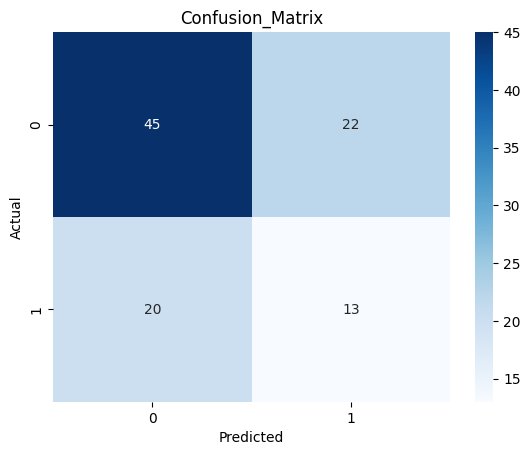

In [106]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion_Matrix")
plt.show()

# Step 23: Classification Report

This gives us more information than accuracy.

In [107]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.69      0.67      0.68        67
         Yes       0.37      0.39      0.38        33

    accuracy                           0.58       100
   macro avg       0.53      0.53      0.53       100
weighted avg       0.59      0.58      0.58       100



```
🚨 But there is a problem with what we just did

Currently our workflow is:

X_train
   ↓
preprocessor.fit()
   ↓
preprocessor.transform()
   ↓
X_train_processed
   ↓
model.fit()

And for prediction:

X_test
   ↓
preprocessor.transform()
   ↓
X_test_processed
   ↓
model.predict()

It works.

But we're manually managing:

Preprocessor
Model

separately.

There's a cleaner way.

# Step 24: Create a Pipeline

In [108]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(class_weight='balanced'))
])

This is a very important concept.
```
We have now combined:

Preprocessor
     +
Logistic Regression

into one object.

Look at what the Pipeline does

Instead of manually doing:

X_train_processed = preprocessor.fit_transform(X_train)

model.fit(X_train_processed, y_train)

we can simply do:

In [109]:
pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


The Pipeline automatically performs:
```
X_train
   ↓
Preprocessor
   ↓
Transformed X_train
   ↓
Logistic Regression
   ↓
Trained Model

That's why pipelines are so useful.

# Step 25: Train the Pipeline

In [110]:
pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Notice something very important.
```
We're giving it:

X_train

not:

X_train_processed

Why?

Because the pipeline handles preprocessing itself.

# Step 26: Predict using the Pipeline

In [111]:
y_pred = pipeline.predict(x_test)

The Pipeline automatically does:
```
X_test
   ↓
Preprocessor
   ↓
Transform
   ↓
Logistic Regression
   ↓
Prediction

So you don't have to manually write:

X_test_processed = preprocessor.transform(X_test)
y_pred = model.predict(X_test_processed)

# Step 27: Evaluate the Pipeline

In [112]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.58
              precision    recall  f1-score   support

          No       0.69      0.67      0.68        67
         Yes       0.37      0.39      0.38        33

    accuracy                           0.58       100
   macro avg       0.53      0.53      0.53       100
weighted avg       0.59      0.58      0.58       100



Now our complete ML workflow is:
```
                loan_approval.csv
                        ↓
                       X, y
                        ↓
                 Train/Test Split
                        ↓
                  ┌─────────────┐
                  │  PIPELINE   │
                  │             │
                  │ Preprocessor│
                  │      ↓      │
                  │ Logistic    │
                  │ Regression  │
                  └─────────────┘
                        ↓
                    Prediction
                        ↓
                   Evaluation

# Step 28: Save the Pipeline

Here's where things become really useful.

Instead of saving only the preprocessor, we can save the entire pipeline.

In [113]:
with open("loan_model.pkl", "wb") as f:
    pickle.dump(pipeline, f)

Now your project folder contains:
```
loan_approval.csv
Loan_Project.ipynb
preprocessing1.pkl
loan_model.pkl

The loan_model.pkl contains:

Preprocessor
     +
Trained Logistic Regression

# Step 29: Load the Pipeline

Imagine we close Jupyter.

Tomorrow, we don't need to retrain the model.

We can simply load it:

In [114]:
with open("loan_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

In [115]:
type(loaded_model)

sklearn.pipeline.Pipeline

In [116]:
loaded_model

# will show that the pipeline contains:

# preprocessor
#     ↓
# LogisticRegression

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Step 30: Give it a NEW applicant

This is the coolest part.

Let's create a completely new applicant.

In [117]:
new_applicant = pd.DataFrame({
    "Age": [30],
    "Gender": ["Male"],
    "Education": ["Graduate"],
    "Employment_Type": ["Salaried"],
    "Income": [50000],
    "Loan_Amount": [200000],
    "Credit_Score": [750],
    "Credit_Risk": ["Low"]
})

Notice:
```
We are not giving it Loan_Approved.

Why?

Because that's what we're asking the model to predict.

Our applicant looks like:

Age              30
Gender           Male
Education        Graduate
Employment       Salaried
Income           50000
Loan Amount      200000
Credit Score     750
Credit Risk      Low

# Step 31: Predict

In [118]:
prediction = loaded_model.predict(new_applicant)
print(prediction)

['Yes']


The output will be something like:
```
['Yes']

or:

['No']

Congratulations. You have just built a basic Loan Approval Prediction system.

# 🧠 Now understand why preprocessing1.pkl exists
```
We started with:

loan_approval.csv

Then created:

preprocessor

Then saved it:

pickle.dump(preprocessor, f)

which produced:

preprocessing1.pkl

Later:

preprocessor = pickle.load(f)

brings that exact object back.

But we also created:

pipeline

which contains:

Preprocessor
     +
Logistic Regression

and saved it as:

loan_model.pkl

So you now understand the difference:

preprocessing1.pkl
        ↓
Only preprocessing

loan_model.pkl
        ↓
Preprocessing
     +
Trained ML model

# ⭐ One final mental picture
```
This is what I want you to remember:

                  RAW APPLICANT
                       │
                       ▼
              ┌─────────────────┐
              │   PREPROCESSOR  │
              │                 │
              │ Numerical       │
              │ → StandardScaler│
              │                 │
              │ Categorical     │
              │ → OneHotEncoder │
              └────────┬────────┘
                       │
                       ▼
              NUMERICAL DATA
                       │
                       ▼
             ┌──────────────────┐
             │ LOGISTIC REGRESS.│
             └────────┬─────────┘
                      │
                      ▼
                LOAN APPROVED?
                  /       \
                YES        NO

And the Pipeline packages the whole thing:

Pipeline
│
├── preprocessor
│
└── model

That's the real reason your original code was loading a preprocessor from a .pkl file. It's not some special ML file.
It's simply a previously saved Python object containing the rules needed to transform raw data in exactly the same way as during training.

# Back to the unresolved problem

"Model is not working accurate, it only predicts 0."

# Option A: class_weight='balanced' (simplest fix — one small change)
```
What it does: Instead of changing your data, it changes how the model penalizes mistakes during training. Normally, every wrong prediction counts equally. With class_weight='balanced', a mistake on the minority class (the rare outcome) is penalized much more heavily than a mistake on the majority class — roughly in proportion to how rare it is.

Analogy: Imagine grading a class where 90 students always get the easy questions right and 10 students face the hard ones. If you weight every question equally, ignoring the hard ones barely hurts your grade. class_weight='balanced' is like saying "the hard questions are worth 9x more" — suddenly it's not worth ignoring them.

Where to change it: In Step 18 (Cell 58) where the standalone model is created, and in Step 24 (Cell 79) where the model is defined inside the Pipeline: